# Web Traffic Time Series Forecasting with Neural Networks 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/competitions/web-traffic-time-series-forecasting/sample_submission_2.csv.zip
/kaggle/input/competitions/web-traffic-time-series-forecasting/sample_submission_1.csv.zip
/kaggle/input/competitions/web-traffic-time-series-forecasting/train_2.csv.zip
/kaggle/input/competitions/web-traffic-time-series-forecasting/key_1.csv.zip
/kaggle/input/competitions/web-traffic-time-series-forecasting/key_2.csv.zip
/kaggle/input/competitions/web-traffic-time-series-forecasting/train_1.csv.zip


In [2]:
import zipfile

In [3]:
train_2_path = '/kaggle/input/competitions/web-traffic-time-series-forecasting/train_2.csv.zip'
key_2_path = '/kaggle/input/competitions/web-traffic-time-series-forecasting/key_2.csv.zip'
sample_sub_2_path = '/kaggle/input/competitions/web-traffic-time-series-forecasting/sample_submission_2.csv.zip'

train_1_path = '/kaggle/input/competitions/web-traffic-time-series-forecasting/train_1.csv.zip'
key_1_path = '/kaggle/input/competitions/web-traffic-time-series-forecasting/key_1.csv.zip'
sample_sub_1_path = '/kaggle/input/competitions/web-traffic-time-series-forecasting/sample_submission_1.csv.zip'

def load_from_zip(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        csv_filename = zip_ref.namelist()[0]
        return pd.read_csv(zip_ref.open(csv_filename))

train = load_from_zip(train_2_path)
key = load_from_zip(key_2_path)
sample_sub = load_from_zip(sample_sub_2_path)

In [4]:
# Set display options
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', 10)

In [5]:
print("TRAIN:")
print(train.shape)
print(train.head(10))

print("\nKEY:")
print(key.shape)
print(key.head(10))

print("\nSAMPLE SUBMISSION:")
print(sample_sub.shape)
print(sample_sub.head(10))

TRAIN:
(145063, 804)
                                                  Page  2015-07-01  \
0              2NE1_zh.wikipedia.org_all-access_spider        18.0   
1               2PM_zh.wikipedia.org_all-access_spider        11.0   
2                3C_zh.wikipedia.org_all-access_spider         1.0   
3           4minute_zh.wikipedia.org_all-access_spider        35.0   
4  52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider         NaN   
5              5566_zh.wikipedia.org_all-access_spider        12.0   
6            91Days_zh.wikipedia.org_all-access_spider         NaN   
7             A'N'D_zh.wikipedia.org_all-access_spider       118.0   
8             AKB48_zh.wikipedia.org_all-access_spider         5.0   
9             ASCII_zh.wikipedia.org_all-access_spider         6.0   

   2015-07-02  2015-07-03  2015-07-04  ...  2017-09-06  2017-09-07  \
0        11.0         5.0        13.0  ...        27.0        29.0   
1        14.0        15.0        18.0  ...        25.0        26.0  

### Adding Categorical Features from the Page Name
We can extract some useful features from the page name, which are separated by underscores, i.e. the website name and the access agent. Later on, we can one-hot encode this as input to our neural network. 

In [6]:
'''
STEP 1: Load & Parse Metadata from Page Names
Input: train_2 with Page column like "AKB48_zh.wikipedia.org_all-access_spider"
Output: train_2 with added columns: site, access_agent
'''

def parse_page_name(page_name):
    parts = page_name.split('_')
    # Last 2 parts are always: site (e.g., zh.wikipedia.org) and access_agent (e.g., all-access_spider)
    site = parts[-3]  
    access_agent = '_'.join(parts[-2:]) # e.g. all-access_spider
    return site, access_agent

train['site'] = train['Page'].apply(lambda x: parse_page_name(x)[0])
train['access_agent'] = train['Page'].apply(lambda x: parse_page_name(x)[1])

In [7]:
print("Unique sites:", train['site'].nunique())
print(train['site'].unique())
print("\nUnique access_agents:", train['access_agent'].nunique())
print(train['access_agent'].unique())

Unique sites: 9
['zh.wikipedia.org' 'fr.wikipedia.org' 'en.wikipedia.org'
 'commons.wikimedia.org' 'ru.wikipedia.org' 'www.mediawiki.org'
 'de.wikipedia.org' 'ja.wikipedia.org' 'es.wikipedia.org']

Unique access_agents: 4
['all-access_spider' 'desktop_all-agents' 'mobile-web_all-agents'
 'all-access_all-agents']


In [8]:
# '''
# STEP 2: Lag Features
# For each article, extract historical visits at specific offsets:
# Column format: "2015-07-01", "2015-07-02", ..., "2017-09-10"
# Lags: t-1, t-7, t-14, t-30, t-90, t-365
# Meaningful for XGBoost???
# '''

# # Get all date columns (exclude 'Page', 'site', 'access_agent')
# date_columns = [col for col in train.columns if col not in ['Page', 'site', 'access_agent']]
# print(f"Total date columns: {len(date_columns)}")
# print(f"Date range: {date_columns[0]} to {date_columns[-1]}")

In [9]:
# # Create lag features
# lag_days = [1, 7, 14, 30, 90, 365]

# for lag in lag_days:
#     # For each lag, take the value from (current_index - lag) positions back
#     # lag=1 means take the value from 1 column back (yesterday)
#     # lag=7 means take the value from 7 columns back (1 week ago)
    
#     train[f'lag_{lag}'] = train[date_columns[-lag]].values  # Take from lag positions back

In [10]:
# print("\nLag features created:")
# train[['Page', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_90', 'lag_365']].head(10)

### 1. Recency
Recent data is the most influential in predicting the next 62 days from September to November 2017.

Therefore, I will train and validate the model on the data from exactly one year before the current set up (with a duration of 26 weeks). The calculations are as below: 

In [11]:
# Only keep actual date columns using a date format check
date_columns = [col for col in train.columns if col.startswith('20')]

print("=== Dataset date range ===")
print(f"First date: {date_columns[0]}")
print(f"Last date:  {date_columns[-1]}")
print(f"Total days: {len(date_columns)}")

print("\n=== Prediction window (from key_2.csv) ===")
pred_start = pd.to_datetime('2017-09-13')
pred_end   = pd.to_datetime('2017-11-13')
pred_days  = (pred_end - pred_start).days + 1  # inclusive
print(f"Predict from: {pred_start.date()}")
print(f"Predict to:   {pred_end.date()}")
print(f"Total days:   {pred_days}")

print("\n=== Validation anchor (same duration, 1 year earlier, with same 2 day gap) ===")
# Last training date is 2017-09-10, gap of Sep 11-12, then prediction starts Sep 13
# Mirror this: 1 year back, last feature date = 2016-09-10, predict 2016-09-13 onwards
val_start  = pd.to_datetime('2016-09-13')
val_end    = val_start + pd.Timedelta(days=pred_days - 1)
feat_anchor = pd.to_datetime('2016-09-10')
print(f"Validation target: {val_start.date()} to {val_end.date()}  ({pred_days} days)")
print(f"Features computed from data up to: {feat_anchor.date()}")

print("\n=== 26 weeks back from feature anchor ===")
weeks_back = feat_anchor - pd.Timedelta(weeks=26)
duration   = (feat_anchor - weeks_back).days
print(f"Feature anchor: {feat_anchor.date()}")
print(f"26 weeks back:  {weeks_back.date()}")
print(f"Duration:       {duration} days")

=== Dataset date range ===
First date: 2015-07-01
Last date:  2017-09-10
Total days: 803

=== Prediction window (from key_2.csv) ===
Predict from: 2017-09-13
Predict to:   2017-11-13
Total days:   62

=== Validation anchor (same duration, 1 year earlier, with same 2 day gap) ===
Validation target: 2016-09-13 to 2016-11-13  (62 days)
Features computed from data up to: 2016-09-10

=== 26 weeks back from feature anchor ===
Feature anchor: 2016-09-10
26 weeks back:  2016-03-12
Duration:       182 days


So train the model from 2016-03-12 up to 2016-09-10. Then validate on data from 2016-09-13 to 2016-11-13. 

### 2. Log Transformation and the Median
Internet traffic is typically heavily right-skewed. Viral articles could have 500,000 visits and so the scale could dominate during our neural network's gradient ascent. That's why we should log-scale it with ```log1p```. For the same reason, we should take the median as our central tendency, and not the mean. 

Only 16 weeks feed into AllVisits as a baseline median of visits, and only the most recent 8 of those weeks become individual features (median_0_1, median_1_2, etc) who represent the deviation from the baseline. 

### 3. Predicting deviations from baseline rather than absolute values (Per-series normalization)

Instead of directly predicting the log-median of visits, our NN should learn something with a simpler range: the log-median of deviation of visits from our baseline. That's why the medians in the next code block is subtracted from the baseline,```AllVisits```. The NN only needs to learn something like: "when I see this deviation pattern, predict +0.2 log units above baseline", then we can add AllVisits back at the end to recover the actual scale. 

In [12]:
'''
STEP 3: Create Median/Recent Traffic Features
(0,1) → columns 0-6   → most recent week  (Sep 4 - Sep 10)
(1,2) → columns 7-13  → 2 weeks ago       (Aug 28 - Sep 3)
(2,3) → columns 14-20 → 3 weeks ago
...
(7,8) → columns 49-55 → 8 weeks ago       (the oldest week)
'''
# Take last 181 days, log1p, reverse (most recent = column 0)
train_hist = np.log1p(train[date_columns[-181:]].values[:, ::-1]).astype('float32')

# AllVisits = overall median across all 181 days (in log space)
# This is the baseline: captures scale of each article
all_visits = np.nanmedian(train_hist, axis=1)  # shape: (145063,)
train['AllVisits'] = all_visits

# 8 individual weekly medians, each baseline-subtracted
periods = [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8)]

for (w1, w2) in periods:
    col_name = f'median_{w1}_{w2}'
    week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)
    train[col_name] = (week_median - all_visits).astype('float32')

train['AllVisits'] = train['AllVisits'].fillna(0).astype('float32')

print("Median features:")
median_cols = ['AllVisits'] + [f'median_{w1}_{w2}' for (w1,w2) in periods]
print(train[['Page'] + median_cols].head(10))
print("\nUnique sites:", train['site'].nunique())
print("Unique access_agents:", train['access_agent'].nunique())

/tmp/ipykernel_22/1281488687.py:14: RuntimeWarning: All-NaN slice encountered
  all_visits = np.nanmedian(train_hist, axis=1)  # shape: (145063,)
/tmp/ipykernel_22/1281488687.py:22: RuntimeWarning: All-NaN slice encountered
  week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)
/tmp/ipykernel_22/1281488687.py:22: RuntimeWarning: All-NaN slice encountered
  week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)
/tmp/ipykernel_22/1281488687.py:22: RuntimeWarning: All-NaN slice encountered
  week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)
/tmp/ipykernel_22/1281488687.py:22: RuntimeWarning: All-NaN slice encountered
  week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)
/tmp/ipykernel_22/1281488687.py:22: RuntimeWarning: All-NaN slice encountered
  week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)
/tmp/ipykernel_22/1281488687.py:22: RuntimeWarning: All-NaN slice encountered
  week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)
/tmp/ipy

Median features:
                                                  Page  AllVisits  median_0_1  \
0              2NE1_zh.wikipedia.org_all-access_spider   3.178054    0.154151   
1               2PM_zh.wikipedia.org_all-access_spider   3.091043    0.167054   
2                3C_zh.wikipedia.org_all-access_spider   1.386294    0.223144   
3           4minute_zh.wikipedia.org_all-access_spider   2.833213    0.000000   
4  52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider   2.708050    0.000000   
5              5566_zh.wikipedia.org_all-access_spider   2.890372   -0.182322   
6            91Days_zh.wikipedia.org_all-access_spider   2.079442    0.000000   
7             A'N'D_zh.wikipedia.org_all-access_spider   3.637586    0.169076   
8             AKB48_zh.wikipedia.org_all-access_spider   3.737670    0.023530   
9             ASCII_zh.wikipedia.org_all-access_spider   3.295837   -0.037740   

   median_1_2  median_2_3  median_3_4  median_4_5  median_5_6  median_6_7  \
0    0.117783 

/tmp/ipykernel_22/1281488687.py:22: RuntimeWarning: All-NaN slice encountered
  week_median = np.nanmedian(train_hist[:, 7*w1:7*w2], axis=1)


In [13]:
'''
STEP 4: Create Statistical Features - Ignore this for now
Coefficient of variation (volatility): std / mean
Non-zero ratio: % of days with traffic (sparsity)
Recent max-min: traffic range in last 30 days
'''

'\nSTEP 4: Create Statistical Features - Ignore this for now\nCoefficient of variation (volatility): std / mean\nNon-zero ratio: % of days with traffic (sparsity)\nRecent max-min: traffic range in last 30 days\n'

In [14]:
'''
STEP 5: Set Up Training Data
Create feature matrix X and target y for Keras training
X = [lag_1, lag_7, lag_30, lag_90, lag_365, median_1w, median_4w, median_8w, site_encoded, access_encoded, CV, ...]
y = actual visits for 63 prediction days

Do a walk-forward split.
'''

# --- CATEGORICAL: one-hot encode site and access_agent ---
sites = train['site'].unique()
accesses = train['access_agent'].unique()

for site in sites:
    train[site] = (train['site'] == site).astype('float32')

for access in accesses:
    train[access] = (train['access_agent'] == access).astype('float32')

site_cols = list(sites)
access_cols = list(accesses)

print("Site columns:", site_cols)
print("Access columns:", access_cols)

Site columns: ['zh.wikipedia.org', 'fr.wikipedia.org', 'en.wikipedia.org', 'commons.wikimedia.org', 'ru.wikipedia.org', 'www.mediawiki.org', 'de.wikipedia.org', 'ja.wikipedia.org', 'es.wikipedia.org']
Access columns: ['all-access_spider', 'desktop_all-agents', 'mobile-web_all-agents', 'all-access_all-agents']


### Per-series Normalization of the target feature
Since our medians are already in the ```log1p - AllVisits``` space, and that is what we want our NN to learn, then we must do the same to our target feature ```y```. 

In [15]:
# --- TARGET: 63 days from 2016-09-13 to 2016-11-13  ---
target_start = date_columns.index('2016-09-13')
target_end = target_start + 63
target_cols = date_columns[target_start:target_end]

print(f"Target window: {target_cols[0]} to {target_cols[-1]}")
print(f"Number of target days: {len(target_cols)}")

# log1p + baseline-subtract the targets (same transformation as medians)
# y_norm = log1p(visits) - AllVisits
y_norm_cols = [c + '_norm' for c in target_cols]
for c, c_norm in zip(target_cols, y_norm_cols):
    train[c_norm] = (np.log1p(train[c]) - train['AllVisits']).astype('float32')

# Fill NaN targets with 0
train[y_norm_cols] = train[y_norm_cols].fillna(0)

Target window: 2016-09-13 to 2016-11-14
Number of target days: 63


### Preparing for NN - Input and Output
The neural network takes three inputs: ```X```, ```X_site``` and ```X_access```  and outputs ```y```. 

```
X         (145063, 8)  — the 8 weekly median deviations per article
                          "how has traffic trended week by week?"

X_site    (145063, 9)  — one-hot: which Wikipedia language is this?
                          [0, 0, 1, 0, 0, 0, 0, 0, 0] = en.wikipedia.org

X_access  (145063, 4)  — one-hot: desktop/mobile/spider/all-agents?
                          [1, 0, 0, 0] = all-access_spider

y         (145063, 63) — the 63 target days, also baseline-subtracted
                          from what the model needs to predict
```                        

In [16]:
# --- FEATURE MATRIX ---
median_cols = [f'median_{w1}_{w2}' for (w1, w2) in periods]

# Three separate arrays, matching his model's three inputs
X        = train[median_cols].values.astype('float32')       # (145063, 8)
X_site   = train[site_cols].values.astype('float32')         # (145063, 9)
X_access = train[access_cols].values.astype('float32')       # (145063, 4)
y        = train[y_norm_cols].values.astype('float32')       # (145063, 63)

print(f"X shape (medians):  {X.shape}")
print(f"X_site shape:       {X_site.shape}")
print(f"X_access shape:     {X_access.shape}")
print(f"y shape (targets):  {y.shape}")

X shape (medians):  (145063, 8)
X_site shape:       (145063, 9)
X_access shape:     (145063, 4)
y shape (targets):  (145063, 63)


## Training the Neural Network

In [17]:
import keras
import keras.backend as K
from keras.models import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras import regularizers
import tensorflow as tf

2026-06-29 12:20:11.805867: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782735611.957330      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782735612.001498      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782735612.367906      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782735612.367935      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782735612.367938      22 computation_placer.cc:177] computation placer alr

### Evaluation Metrics
The contest is judged based on SMAPE, Symmetric Mean Percentage Error.

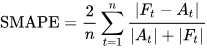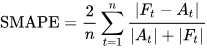

where $A_t$ are the actual values and $F_t$ are the forecasted values. Note that if $A_t = F_t = 0$, then term $t$ is undefined $(0/0)$, and is usually ignored in the summation.

The MAPE and SMAPE are good metrics of evaluation for data where 0 is a meaningful value, e.g
1. Views: 0 views = no one visited (as in this case)
2. Sales: 0 sales = no money made etc

Non-meaningful zero examples:
1. Temperature in Celsius: 0°C is just a point, not "no temperature"
2. Temperature in Fahrenheit: 32°F = 0°C, arbitrary

The use of SMAPE rather than MAPE here is because MAPE tends to penalize overforecasts and favours models that underpredict, while Internet views can sometimes be blown off-proportion due to virality.

In [18]:
'''
STEP 6: Keras Model (Shallow NN)
Input: features from Step 5
Dense(128, relu) → Dropout(0.3)
Dense(64, relu) → Dropout(0.3)
Dense(63) → output for 63 days

Loss: Smoothed SMAPE
Optimizer: Adam
Train with K-fold CV
'''

# STEP 6a: Define model and SMAPE loss
def smape_error(y_true, y_pred):
    return tf.reduce_mean(tf.clip_by_value(tf.abs(y_pred - y_true), 0.0, 1.0), axis=-1)
    
# Fix smape function to handle NaN in y_true
def smape(y_true, y_pred):
    y_true = np.nan_to_num(y_true, nan=0.0)
    y_pred = np.nan_to_num(y_pred, nan=0.0)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    result = np.where(denominator == 0, 0.0, diff / np.where(denominator == 0, 1.0, denominator))
    return np.mean(result)

### The Shallow Neural Network
The input is three separate arrays fed in simultaneously:

1. main_input: the 8 weekly median deviations
2. site_input: 9-element one-hot for which Wikipedia language domain
3. access_input: 4-element one-hot for desktop/mobile/spider/all-access

These three are immediately concatenated into one flat vector x0 of size 8+9+4 = 21 values. This is just gluing them together so the network sees everything at once.

#### Layer 1, Dense(200) + Dropout:

```x0 (21) → Dense(200) → relu → Dropout(0.5) → x (200)```

Learns 200 abstract combinations of the 21 input features. Dropout randomly zeroes out half the neurons during training to prevent overfitting.

#### Skip connection:
The original 21 inputs are glued back onto the 200 outputs from layer 1. This gives the next layer direct access to the raw features again, it doesn't have to "remember" them through layer 1. Borrowed from ResNet-style thinking.

#### Layer 2, Dense(200) + BatchNorm + Dropout:

```(221) → Dense(200) → BatchNorm → relu → Dropout(0.5) → x (200)```

BatchNorm normalizes the activations across the batch, stabilizing training.

#### Layers 3 & 4, Dense(100) then Dense(200) + Dropout:

```(200) → Dense(100) → relu → Dropout → Dense(200) → relu → Dropout → x (200)```

The bottleneck at 100 forces the network to compress its representation before expanding again. Common pattern for learning compact features.

#### Output, Dense(63), linear activation:

```(200) → Dense(63) → raw floats (no activation)```

One output per prediction day. Linear activation means no clamping, so just raw values in log-normalized space. We decode these later with expm1(pred + AllVisits).

The skip connection is important because without it, the raw median and categorical features get increasingly diluted as they pass through layers. By feeding x0 directly into layer 2, the network can still "look back" at the original inputs when making its final prediction.

In [19]:
def get_model(input_dim, num_sites, num_accesses, output_dim):
    dropout = 0.5
    regularizer = 0.00004

    main_input   = Input(shape=(input_dim,),    dtype='float32', name='main_input')
    site_input   = Input(shape=(num_sites,),    dtype='float32', name='site_input')
    access_input = Input(shape=(num_accesses,), dtype='float32', name='access_input')

    # Concatenate all inputs together
    x0 = keras.layers.concatenate([main_input, site_input, access_input])

    x = Dense(200, activation='relu', kernel_initializer='lecun_uniform',
              kernel_regularizer=regularizers.l2(regularizer))(x0)
    x = Dropout(dropout)(x)

    # Skip connection: concatenate original input back in
    x = keras.layers.concatenate([x0, x])
    x = Dense(200, activation='relu', kernel_initializer='lecun_uniform',
              kernel_regularizer=regularizers.l2(regularizer))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    x = Dense(100, activation='relu', kernel_initializer='lecun_uniform',
              kernel_regularizer=regularizers.l2(regularizer))(x)
    x = Dropout(dropout)(x)

    x = Dense(200, activation='relu', kernel_initializer='lecun_uniform',
              kernel_regularizer=regularizers.l2(regularizer))(x)
    x = Dropout(dropout)(x)

    # Output: one value per prediction day (63 days)
    x = Dense(output_dim, activation='linear', kernel_initializer='lecun_uniform',
              kernel_regularizer=regularizers.l2(regularizer))(x)

    model = Model(inputs=[main_input, site_input, access_input], outputs=[x])
    model.compile(loss=smape_error, optimizer='adam')
    return model

print(f"Model inputs: medians={X.shape[1]}, sites={X_site.shape[1]}, accesses={X_access.shape[1]}")
print(f"Model output: {y.shape[1]} days")

Model inputs: medians=8, sites=9, accesses=4
Model output: 63 days


### Data Imputation - Zero-fill
I decided on zero-fill here because it was stated that zeros in the original dataset could either imply missing data or zero traffic. Since zeroes are meaningful and could serve as a default state to indicate no traffic, a zero-fill suits our purpose here. 

### Training

The dataset ranges from 2015-2017, but the model is first trained on data from 2016, to validate against data from 2016. The assumption is that what we learned in most recent years (2016) could be used to predict our data for the target in 2017.

In [20]:
from sklearn.model_selection import GroupKFold

In [21]:
# We need TWO sets of features:
# 1. Features from the 2016 window -> paired with 2016 targets (for training/validation)
# 2. Features from the 2017 window -> used for final submission predictions

# --- 2016 window: 181 days ending at 2016-09-10 ---
idx_2016_end = date_columns.index('2016-09-10') + 1  # +1 for slicing
train_hist_2016 = np.log1p(
    train[date_columns[idx_2016_end - 181 : idx_2016_end]].values[:, ::-1]
).astype('float32')

all_visits_2016 = np.nanmedian(train_hist_2016, axis=1)
all_visits_2016 = np.nan_to_num(all_visits_2016, nan=0.0).astype('float32')

X_2016 = np.zeros((len(train), 8), dtype='float32')
for j, (w1, w2) in enumerate(periods):
    week_med = np.nanmedian(train_hist_2016[:, 7*w1:7*w2], axis=1)
    X_2016[:, j] = np.nan_to_num(week_med - all_visits_2016, nan=0.0)

# --- 2017 window: 181 days ending at 2017-09-10 (already computed as X) ---
# X, X_site, X_access, all_visits are already from 2017 — keep for final submission

# --- Targets: 2016-09-13 to 2016-11-14 (log-normalized against 2016 baseline) ---
y_norm_cols_2016 = [c + '_norm' for c in target_cols]
for c, c_norm in zip(target_cols, y_norm_cols_2016):
    train[c_norm] = (np.log1p(train[c]) - all_visits_2016).astype('float32')
train[y_norm_cols_2016] = train[y_norm_cols_2016].fillna(0)

y_2016 = train[y_norm_cols_2016].values.astype('float32')
y_true_raw_2016 = np.nan_to_num(train[target_cols].values.astype('float32'), nan=0.0)
all_visits_2016_col = all_visits_2016  # keep for decoding

print(f"X_2016 shape: {X_2016.shape}")
print(f"y_2016 shape: {y_2016.shape}")
print(f"NaNs in X_2016: {np.isnan(X_2016).sum()}")
print(f"NaNs in y_2016: {np.isnan(y_2016).sum()}")
print(f"\nSample X_2016[0]: {X_2016[0]}")
print(f"Sample y_2016[0,:3]: {y_2016[0,:3]}")

/tmp/ipykernel_22/3037964739.py:11: RuntimeWarning: All-NaN slice encountered
  all_visits_2016 = np.nanmedian(train_hist_2016, axis=1)
/tmp/ipykernel_22/3037964739.py:16: RuntimeWarning: All-NaN slice encountered
  week_med = np.nanmedian(train_hist_2016[:, 7*w1:7*w2], axis=1)


X_2016 shape: (145063, 8)
y_2016 shape: (145063, 63)
NaNs in X_2016: 0
NaNs in y_2016: 0

Sample X_2016[0]: [0.05129337 0.14660358 0.10008359 0.27443695 0.351398   0.05129337
 0.         0.        ]
Sample y_2016[0,:3]: [-0.4595323 -0.3053816  0.1000835]


In [22]:
n_folds = 5
kf = GroupKFold(n_splits=n_folds)
group = pd.factorize(train['Page'])[0]
batch_size = 4096

y_pred_oof = np.zeros_like(y_2016)
best_smape = 100.0

for fold, (train_idx, val_idx) in enumerate(kf.split(X_2016, y_2016, group)):
    print(f"\n--- Fold {fold+1}/{n_folds} ---")

    X_tr,  X_va  = X_2016[train_idx],    X_2016[val_idx]
    Xs_tr, Xs_va = X_site[train_idx],    X_site[val_idx]
    Xa_tr, Xa_va = X_access[train_idx],  X_access[val_idx]
    y_tr,  y_va  = y_2016[train_idx],    y_2016[val_idx]

    model = get_model(X_2016.shape[1], X_site.shape[1], X_access.shape[1], y_2016.shape[1])

    model.fit(
        [X_tr, Xs_tr, Xa_tr], y_tr,
        epochs=100,
        batch_size=batch_size,
        verbose=0,
        shuffle=True
    )

    y_pred = model.predict([X_va, Xs_va, Xa_va], batch_size=batch_size)
    y_pred_oof[val_idx] = y_pred

    # Decode: add back 2016 baseline, then expm1
    y_pred_decoded = np.expm1(y_pred + all_visits_2016_col[val_idx].reshape(-1, 1))
    y_pred_decoded = np.clip(y_pred_decoded, 0, None).round()

    fold_smape = smape(y_true_raw_2016[val_idx], y_pred_decoded)
    print(f"Fold {fold+1} SMAPE: {fold_smape:.5f}")

    if fold_smape < best_smape:
        best_smape = fold_smape

print(f"\nBest fold SMAPE: {best_smape:.5f}")


--- Fold 1/5 ---


I0000 00:00:1782735628.221939      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782735628.227786      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1782735631.458301      70 service.cc:152] XLA service 0x7a35b400e290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782735631.458335      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782735631.458339      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782735631.904499      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782735635.529729      70 device_compiler.h:188] Compiled clust

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
Fold 1 SMAPE: 0.44302

--- Fold 2/5 ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Fold 2 SMAPE: 0.44453

--- Fold 3/5 ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Fold 3 SMAPE: 0.44576

--- Fold 4/5 ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step
Fold 4 SMAPE: 0.44578

--- Fold 5/5 ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Fold 5 SMAPE: 0.44138

Best fold SMAPE: 0.44138


In [23]:
# Train final model on ALL data using 2017 features
# No validation fold we use everything for the final submission

final_model = get_model(X.shape[1], X_site.shape[1], X_access.shape[1], y_2016.shape[1])

final_model.fit(
    [X, X_site, X_access], y_2016,
    epochs=100,
    batch_size=4096,
    verbose=1,
    shuffle=True
)

print("Final model trained.")

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: nan
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: nan
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: nan
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: nan
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: nan
Epoch 13/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: nan
Epoch 14/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: nan
Epoch 15/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: nan
Epoch 16/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

In [24]:
# Predict on the 2017 window (full dataset, all 145063 articles)
y_pred_final = final_model.predict([X, X_site, X_access], batch_size=4096)

# Decode: add back 2017 baseline, then expm1
y_pred_submission = np.expm1(y_pred_final + all_visits.reshape(-1, 1))
y_pred_submission = np.clip(y_pred_submission, 0, None).round().astype(int)

print(f"Predictions shape: {y_pred_submission.shape}")
print(f"Sample predictions (first article, first 5 days): {y_pred_submission[0, :5]}")
print(f"Min: {y_pred_submission.min()}, Max: {y_pred_submission.max()}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Predictions shape: (145063, 63)
Sample predictions (first article, first 5 days): [-9223372036854775808 -9223372036854775808 -9223372036854775808
 -9223372036854775808 -9223372036854775808]
Min: -9223372036854775808, Max: -9223372036854775808


/tmp/ipykernel_22/3995040475.py:6: RuntimeWarning: invalid value encountered in cast
  y_pred_submission = np.clip(y_pred_submission, 0, None).round().astype(int)


Now, all we have to do is build the submission dataframe.

In [25]:
# Build submission dataframe

# target_cols are the 63 prediction dates (2016 window), we need 2017 dates
# The actual submission dates are 2017-09-13 to 2017-11-13
submission_dates = pd.date_range('2017-09-13', '2017-11-13').strftime('%Y-%m-%d').tolist()
print("Submission dates:", submission_dates[0], "to", submission_dates[-1])

# Build a long-form dataframe: one row per (article, date)
pages = train['Page'].values  # 145063 articles

rows = []
for i, date in enumerate(submission_dates):
    df_date = pd.DataFrame({
        'Page': pages,
        'Date': date,
        'Visits': y_pred_submission[:, i]
    })
    rows.append(df_date)

predictions_long = pd.concat(rows, ignore_index=True)
print(f"Long-form predictions shape: {predictions_long.shape}")
print(predictions_long.head())

Submission dates: 2017-09-13 to 2017-11-13
Long-form predictions shape: (8993906, 3)
                                                  Page        Date  \
0              2NE1_zh.wikipedia.org_all-access_spider  2017-09-13   
1               2PM_zh.wikipedia.org_all-access_spider  2017-09-13   
2                3C_zh.wikipedia.org_all-access_spider  2017-09-13   
3           4minute_zh.wikipedia.org_all-access_spider  2017-09-13   
4  52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider  2017-09-13   

                Visits  
0 -9223372036854775808  
1 -9223372036854775808  
2 -9223372036854775808  
3 -9223372036854775808  
4 -9223372036854775808  


In [26]:
# Merge with key_2 to get the Id column
# key has columns: Page (= article + date), Id
# We need to reconstruct the key's Page format: "article_date"
key['ArticlePage'] = key['Page'].apply(lambda x: x[:-11])  # strip trailing _YYYY-MM-DD
key['Date'] = key['Page'].apply(lambda x: x[-10:])         # last 10 chars = date

submission = predictions_long.merge(
    key[['ArticlePage', 'Date', 'Id']],
    left_on=['Page', 'Date'],
    right_on=['ArticlePage', 'Date'],
    how='left'
)

submission = submission[['Id', 'Visits']].sort_values('Id').reset_index(drop=True)

print(f"Submission shape: {submission.shape}")
print(f"Null Ids: {submission['Id'].isnull().sum()}")
print(submission.head(10))

Submission shape: (8993906, 2)
Null Ids: 0
             Id               Visits
0  0000009abb1c -9223372036854775808
1  0000023b7434 -9223372036854775808
2  000002ddbe6e -9223372036854775808
3  0000032f82ac -9223372036854775808
4  000003e266a3 -9223372036854775808
5  000005c4dae8 -9223372036854775808
6  00000739df42 -9223372036854775808
7  0000074046ad -9223372036854775808
8  00000afca055 -9223372036854775808
9  00000afd6648 -9223372036854775808


In [27]:
submission.to_csv('/kaggle/working/submission.csv', index=False)
print("Saved!")
print(submission.shape)
print(submission.head())

Saved!
(8993906, 2)
             Id               Visits
0  0000009abb1c -9223372036854775808
1  0000023b7434 -9223372036854775808
2  000002ddbe6e -9223372036854775808
3  0000032f82ac -9223372036854775808
4  000003e266a3 -9223372036854775808


#### Final Submission SMAPE: 40.47791

In [28]:
'''
WIP - XGBoost on Residuals
residuals = y_actual - y_keras_predictions
XGBoost features: same as Keras, but add interactions like median * day_of_week
Target: predict residuals
Combine: final = keras_pred + xgb_residual_pred 
'''

'\nWIP - XGBoost on Residuals\nresiduals = y_actual - y_keras_predictions\nXGBoost features: same as Keras, but add interactions like median * day_of_week\nTarget: predict residuals\nCombine: final = keras_pred + xgb_residual_pred \n'